## Setup: Install Libraries

In [4]:
!pip install -q requests beautifulsoup4 lxml pandas tqdm

## Setup: Import Libraries

In [5]:
import time
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin
from tqdm.auto import tqdm

## Initial Request to Base URL

In [6]:
BASE_URL = "https://sandbox.oxylabs.io/"

HEADERS = {
    "User-Agent": (
        "Mozilla/5.0 "
        "(Educational Web Scraping Project; Python requests)"
    )
}

response = requests.get(
    BASE_URL,
    headers=HEADERS,
    timeout=20
)

print("Status code:", response.status_code)
print("Final URL:", response.url)
print(response.text[:500])

Status code: 200
Final URL: https://sandbox.oxylabs.io/
<!DOCTYPE html><html lang="en"><head><meta charSet="utf-8"/><meta name="viewport" content="width=device-width"/><link rel="icon" href="/favicon.ico"/><title>Scraping Sandbox | Oxylabs</title><meta name="description"/><meta property="og:title" content="Scraping Sandbox | Oxylabs"/><meta property="og:description"/><meta property="og:developer"/><meta property="og:platform"/><meta property="og:type"/><meta property="og:currency"/><meta property="og:price"/><meta property="og:image" content="https:/


## Analyze Base URL HTML

In [7]:
soup = BeautifulSoup(response.text, "html.parser")

print("Page title:", soup.title.get_text(strip=True))

print("\nFirst 20 links:")
for link in soup.select("a[href]")[:20]:
    print(
        link.get_text(" ", strip=True),
        "->",
        urljoin(BASE_URL, link.get("href"))
    )

print("\nCommon CSS classes:")
classes = []

for tag in soup.find_all(True):
    classes.extend(tag.get("class", []))

print(pd.Series(classes).value_counts().head(30))

Page title: Scraping Sandbox | Oxylabs

First 20 links:
 -> https://sandbox.oxylabs.io/
games store -> https://sandbox.oxylabs.io/products

Common CSS classes:
css-gvwmfq     1
egbpcqk5       1
css-qiikdh     1
egbpcqk4       1
css-t3d3qw     1
egbpcqk3       1
css-qwo52f     1
emaf2uu8       1
css-ssz5rk     1
emaf2uu7       1
css-10idikp    1
emaf2uu6       1
css-7g428u     1
e1nywbhn4      1
css-1jmw9fa    1
emaf2uu0       1
css-1m0fovo    1
emaf2uu1       1
css-1g868uz    1
emaf2uu3       1
css-7b2abb     1
emaf2uu2       1
css-wp13wg     1
emaf2uu4       1
css-1ywglsu    1
emaf2uu5       1
Name: count, dtype: int64


## Extract and Filter Product-Like Links from Base URL

In [8]:
all_links = []

for link in soup.select("a[href]"):
    href = link.get("href")
    text = link.get_text(" ", strip=True)

    full_url = urljoin(BASE_URL, href)

    all_links.append({
        "link_text": text,
        "href": href,
        "full_url": full_url
    })

links_df = pd.DataFrame(all_links).drop_duplicates()

product_like_links = links_df[
    links_df["full_url"].str.contains(
        r"product|game|item",
        case=False,
        regex=True,
        na=False
    )
]

display(product_like_links.head(30))

,link_text,href,full_url
1,games store,/products,https://sandbox.oxylabs.io/products


## Display Unique HREFs

In [9]:
print(
    links_df["href"]
    .dropna()
    .drop_duplicates()
    .head(100)
    .to_list()
)

['/', '/products']


## Test Candidate Product Listing URLs

In [10]:
candidate_urls = [
    "https://sandbox.oxylabs.io/products",
    "https://sandbox.oxylabs.io/store",
    "https://sandbox.oxylabs.io/category",
    "https://sandbox.oxylabs.io/search"
]

for url in candidate_urls:
    try:
        test_response = requests.get(
            url,
            headers=HEADERS,
            timeout=15
        )

        print(
            f"URL: {url}\n"
            f"Status: {test_response.status_code}\n"
            f"Final URL: {test_response.url}\n"
            f"Page title: {BeautifulSoup(test_response.text, 'html.parser').title}\n"
        )

    except Exception as error:
        print(f"Could not access {url}: {error}\n")

URL: https://sandbox.oxylabs.io/products
Status: 200
Final URL: https://sandbox.oxylabs.io/products
Page title: <title>E-commerce	| Oxylabs Scraping Sandbox</title>

URL: https://sandbox.oxylabs.io/store
Status: 404
Final URL: https://sandbox.oxylabs.io/store
Page title: <title>404: This page could not be found</title>

URL: https://sandbox.oxylabs.io/category
Status: 404
Final URL: https://sandbox.oxylabs.io/category
Page title: <title>404: This page could not be found</title>

URL: https://sandbox.oxylabs.io/search
Status: 404
Final URL: https://sandbox.oxylabs.io/search
Page title: <title>404: This page could not be found</title>



## Request and Parse Product Listing Page

In [11]:
LISTING_URL = "https://sandbox.oxylabs.io/products"

listing_response = requests.get(
    LISTING_URL,
    headers=HEADERS,
    timeout=20
)

listing_response.raise_for_status()

listing_soup = BeautifulSoup(
    listing_response.text,
    "html.parser"
)

print("Status code:", listing_response.status_code)
print("Page title:", listing_soup.title.get_text(strip=True))

print("\nFirst 30 links on the product page:\n")

for link in listing_soup.select("a[href]")[:30]:
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    print(f"{text[:60]:60} -> {urljoin(LISTING_URL, href)}")

Status code: 200
Page title: E-commerce	| Oxylabs Scraping Sandbox

First 30 links on the product page:

                                                             -> https://sandbox.oxylabs.io/
Nintendo platform                                            -> https://sandbox.oxylabs.io/products/category/nintendo
Xbox platform                                                -> https://sandbox.oxylabs.io/products/category/xbox-platform
Playstation platform                                         -> https://sandbox.oxylabs.io/products/category/playstation-platform
The Legend of Zelda: Ocarina of Time                         -> https://sandbox.oxylabs.io/products/1
Add to Basket                                                -> https://sandbox.oxylabs.io/products
Super Mario Galaxy                                           -> https://sandbox.oxylabs.io/products/2
Add to Basket                                                -> https://sandbox.oxylabs.io/products
Super Mario Galaxy 2        

## Identify Product Card Selectors

In [12]:
candidate_selectors = [
    ".product",
    ".product-card",
    ".card",
    "[class*='product']",
    "[class*='Product']",
    "[class*='item']",
    "[class*='Item']",
    "[data-testid*='product']"
]

for selector in candidate_selectors:
    try:
        elements = listing_soup.select(selector)
        print(f"{selector:30} -> {len(elements)} elements")
    except Exception as error:
        print(f"{selector:30} -> ERROR: {error}")

.product                       -> 0 elements
.product-card                  -> 32 elements
.card                          -> 0 elements
[class*='product']             -> 33 elements
[class*='Product']             -> 0 elements
[class*='item']                -> 0 elements
[class*='Item']                -> 0 elements
[data-testid*='product']       -> 0 elements


## Inspect First Product Card HTML

In [13]:
product_candidates = listing_soup.select(
    "[class*='product'], [class*='Product']"
)

print("Potential product elements found:", len(product_candidates))

if product_candidates:
    print(product_candidates[0].prettify()[:5000])
else:
    print("No product candidates found with this selector.")

Potential product elements found: 33
<div class="products-wrapper css-phdzty e1kord975">
 <style data-emotion="css e8at8d">
  .css-e8at8d{display:grid;position:relative;background-color:#ffffff;padding:1.5rem;border-radius:5px;}
 </style>
 <div class="product-card css-e8at8d eag3qlw10">
  <style data-emotion="css 15g2oxy">
   .css-15g2oxy{margin-top:1rem;}
  </style>
  <div class="css-15g2oxy eag3qlw3">
  </div>
  <style data-emotion="css o171kl">
   .css-o171kl{-webkit-text-decoration:none;text-decoration:none;color:inherit;}
  </style>
  <a class="card-header css-o171kl eag3qlw2" href="/products/1">
   <span style="box-sizing:border-box;display:block;overflow:hidden;width:initial;height:initial;background:none;opacity:1;border:0;margin:0;padding:0;position:relative">
    <span style="box-sizing:border-box;display:block;width:initial;height:initial;background:none;opacity:1;border:0;margin:0;padding:0;padding-top:100%">
    </span>
    
    <noscript>
     <img alt="The_Legend_of_Zeld

## Extract Product Links from Listing Page

In [14]:
product_links = []

for link in listing_soup.select("a[href]"):
    href = link.get("href", "")
    text = link.get_text(" ", strip=True)

    full_url = urljoin(LISTING_URL, href)

    if "/products/" in full_url and full_url != LISTING_URL:
        product_links.append({
            "product_name_from_link": text,
            "product_url": full_url
        })

product_links_df = (
    pd.DataFrame(product_links)
    .drop_duplicates(subset=["product_url"])
    .reset_index(drop=True)
)

print("Unique product links found:", len(product_links_df))

display(product_links_df.head(20))

Unique product links found: 35


,product_name_from_link,product_url
0,Nintendo platform,https://sandbox.oxylabs.io/products/category/n...
1,Xbox platform,https://sandbox.oxylabs.io/products/category/x...
2,Playstation platform,https://sandbox.oxylabs.io/products/category/p...
3,The Legend of Zelda: Ocarina of Time,https://sandbox.oxylabs.io/products/1
4,Super Mario Galaxy,https://sandbox.oxylabs.io/products/2
5,Super Mario Galaxy 2,https://sandbox.oxylabs.io/products/3
6,Metroid Prime,https://sandbox.oxylabs.io/products/4
7,Super Mario Odyssey,https://sandbox.oxylabs.io/products/5
8,Halo: Combat Evolved,https://sandbox.oxylabs.io/products/6
9,The House in Fata Morgana - Dreams of the Reve...,https://sandbox.oxylabs.io/products/7


## Scrape Details of a Single Product for Testing

In [15]:
first_product_url = product_links_df.loc[0, "product_url"]

product_response = requests.get(
    first_product_url,
    headers=HEADERS,
    timeout=20
)

product_response.raise_for_status()

product_soup = BeautifulSoup(
    product_response.text,
    "html.parser"
)

print("Product URL:", first_product_url)
print("Page title:", product_soup.title.get_text(strip=True))

print("\nMain heading:")
print(product_soup.select_one("h1").get_text(" ", strip=True))

print("\nFirst 4000 characters of visible page text:")
print(product_soup.get_text(" ", strip=True)[:4000])

Product URL: https://sandbox.oxylabs.io/products/category/nintendo
Page title: nintendo | Oxylabs Scraping Sandbox

Main heading:
Video Games to scrape

First 4000 characters of visible page text:
nintendo | Oxylabs Scraping Sandbox Game platforms: All Nintendo platform wii wii-u nintendo-64 switch gamecube game-boy-advance 3ds ds Xbox platform Dreamcast Playstation platform Pc Stadia Note ! This is a sandbox website used for web scraping. Information listed in this website does not have any real meaning and should not be associated with the actual products. Video Games to scrape Filtered: nintendo 832 results - showing 1 to 32 The Legend of Zelda: Ocarina of Time Action Adventure Fantasy As a young boy, Link is tricked by Ganondorf, the King of the Gerudo Thieves. The evil human uses Link to gain access to the Sacred Realm, where he places his tainted hands on Triforce and transforms the beautiful Hyrulean landscape into a barren wasteland. Link is determined to fix the problems he he

## Define Helper Functions for Product Detail Scraping

In [16]:
import re

def clean_text(text):
    return re.sub(
        r"\s+",
        " ",
        str(text)
    ).strip()


def extract_price(page_text):
    patterns = [
        r"\$\s?[\d,]+(?:\.\d{1,2})?",
        r"€\s?[\d,]+(?:\.\d{1,2})?",
        r"£\s?[\d,]+(?:\.\d{1,2})?"
    ]

    for pattern in patterns:
        match = re.search(pattern, page_text)

        if match:
            return match.group(0)

    return None


def scrape_product_detail(product_url):
    response = requests.get(
        product_url,
        headers=HEADERS,
        timeout=20
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    page_text = clean_text(
        soup.get_text(" ", strip=True)
    )

    title_tag = soup.select_one("h1")
    product_name = (
        clean_text(title_tag.get_text(" ", strip=True))
        if title_tag else None
    )

    price = extract_price(page_text)

    image_tag = soup.select_one("img")

    image_url = None

    if image_tag:
        image_source = (
            image_tag.get("src")
            or image_tag.get("data-src")
            or image_tag.get("srcset")
        )

        if image_source:
            image_url = urljoin(
                product_url,
                image_source
            )

    description_tag = soup.select_one(
        "[class*='description'], "
        "[class*='Description'], "
        "[class*='details'], "
        "[class*='Details']"
    )

    description = (
        clean_text(description_tag.get_text(" ", strip=True))
        if description_tag else None
    )

    breadcrumbs = [
        clean_text(item.get_text(" ", strip=True))
        for item in soup.select(
            "nav a, "
            "[class*='breadcrumb'] a, "
            "[class*='Breadcrumb'] a"
        )
    ]

    return {
        "product_name": product_name,
        "price_raw": price,
        "description": description,
        "breadcrumbs": " > ".join(breadcrumbs),
        "image_url": image_url,
        "product_url": product_url
    }

## Test Product Detail Scraping Function

In [17]:
one_product = scrape_product_detail(first_product_url)

one_product

{'product_name': 'Video Games to scrape',
 'price_raw': None,
 'description': 'As a young boy, Link is tricked by Ganondorf, the King of the Gerudo Thieves. The evil human uses Link to gain access to the Sacred Realm, where he places his tainted hands on Triforce and transforms the beautiful Hyrulean landscape into a barren wasteland. Link is determined to fix the problems he helped to create, so with the help of Rauru he travels through time gathering the powers of the Seven Sages.',
 'breadcrumbs': '',
 'image_url': 'data:image/svg+xml,%3csvg%20xmlns=%27http://www.w3.org/2000/svg%27%20version=%271.1%27%20width=%27350%27%20height=%2750%27/%3e',
 'product_url': 'https://sandbox.oxylabs.io/products/category/nintendo'}

## Scrape All Identified Product Details

In [18]:
scraped_products = []

for product_url in tqdm(product_links_df["product_url"]):
    try:
        record = scrape_product_detail(product_url)
        scraped_products.append(record)

        time.sleep(0.8)

    except Exception as error:
        print(f"Error scraping {product_url}: {error}")

products_df = pd.DataFrame(scraped_products)

print("Products scraped:", len(products_df))

display(products_df.head(10))

  0%|          | 0/35 [00:00<?, ?it/s]

Products scraped: 35


,product_name,price_raw,description,breadcrumbs,image_url,product_url
0,Video Games to scrape,None,"As a young boy, Link is tricked by Ganondorf, ...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/category/n...
1,Video Games to scrape,None,"Enter the mysterious world of Halo, an alien p...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/category/x...
2,Video Games to scrape,$30,Fortune hunter Nathan Drake returns in Unchart...,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/category/p...
3,None,None,"As a young boy, Link is tricked by Ganondorf, ...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/1
4,None,None,[Metacritic's 2007 Wii Game of the Year] The u...,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/2
5,None,None,"Super Mario Galaxy 2, the sequel to the galaxy...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/3
6,None,None,Samus returns in a new mission to unravel the ...,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/4
7,None,None,New Evolution of Mario Sandbox-Style Gameplay....,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/5
8,None,None,"Enter the mysterious world of Halo, an alien p...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/6
9,None,None,A gothic suspense tale set in a cursed mansion...,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/7


## Initial Data Cleaning and Inspection (Old)

In [19]:
products_df["price_numeric"] = (
    products_df["price_raw"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)

products_df["price_numeric"] = pd.to_numeric(
    products_df["price_numeric"],
    errors="coerce"
)

products_df = products_df.drop_duplicates(
    subset=["product_url"]
).reset_index(drop=True)

print("Final dataset shape:", products_df.shape)

print("\nMissing values:")
print(products_df.isnull().sum())

display(products_df.head())

Final dataset shape: (35, 7)

Missing values:
product_name     32
price_raw        33
description       0
breadcrumbs       0
image_url         0
product_url       0
price_numeric    33
dtype: int64


,product_name,price_raw,description,breadcrumbs,image_url,product_url,price_numeric
0,Video Games to scrape,None,"As a young boy, Link is tricked by Ganondorf, ...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/category/n...,NaN
1,Video Games to scrape,None,"Enter the mysterious world of Halo, an alien p...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/category/x...,NaN
2,Video Games to scrape,$30,Fortune hunter Nathan Drake returns in Unchart...,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/category/p...,30.0
3,None,None,"As a young boy, Link is tricked by Ganondorf, ...",,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/1,NaN
4,None,None,[Metacritic's 2007 Wii Game of the Year] The u...,,"data:image/svg+xml,%3csvg%20xmlns=%27http://ww...",https://sandbox.oxylabs.io/products/2,NaN


## Save Scraped Data (Old)

In [20]:
products_df.to_csv(
    "oxylabs_scraped_products.csv",
    index=False
)

print("Saved file: oxylabs_scraped_products.csv")

Saved file: oxylabs_scraped_products.csv


## Extract Pagination Links (Old)

In [21]:
pagination_links = []

for link in listing_soup.select("a[href]"):
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    if (
        "page" in str(href).lower()
        or text.lower() in ["next", ">", "›", "»"]
        or text.isdigit()
    ):
        pagination_links.append({
            "text": text,
            "url": urljoin(LISTING_URL, href)
        })

pagination_df = pd.DataFrame(pagination_links).drop_duplicates()

display(pagination_df)

,text,url
0,1,https://sandbox.oxylabs.io/products?page=1
1,2,https://sandbox.oxylabs.io/products?page=2
2,3,https://sandbox.oxylabs.io/products?page=3
3,4,https://sandbox.oxylabs.io/products?page=4
4,5,https://sandbox.oxylabs.io/products?page=5
5,93,https://sandbox.oxylabs.io/products?page=93
6,94,https://sandbox.oxylabs.io/products?page=94
7,Forward,https://sandbox.oxylabs.io/products?page=2


## Test Product Card Selectors on a Paginated Page (Old)

In [22]:
TEST_URL = "https://sandbox.oxylabs.io/products?page=1"

response = requests.get(
    TEST_URL,
    headers=HEADERS,
    timeout=20
)

response.raise_for_status()

test_soup = BeautifulSoup(
    response.text,
    "html.parser"
)

candidate_selectors = [
    ".product",
    ".product-card",
    ".card",
    "[class*='product']",
    "[class*='Product']",
    "[class*='item']",
    "[class*='Item']",
    "[data-testid*='product']"
]

for selector in candidate_selectors:
    matches = test_soup.select(selector)
    print(f"{selector:30} -> {len(matches)} elements")

.product                       -> 0 elements
.product-card                  -> 32 elements
.card                          -> 0 elements
[class*='product']             -> 33 elements
[class*='Product']             -> 0 elements
[class*='item']                -> 0 elements
[class*='Item']                -> 0 elements
[data-testid*='product']       -> 0 elements


## Inspect First Product Card HTML from Paginated Page (Old)

In [23]:
cards = test_soup.select("[class*='product'], [class*='Product']")

print("Potential cards:", len(cards))

if cards:
    print(cards[0].prettify()[:6000])
else:
    print("No cards found. Print test_soup.prettify()[:10000] for inspection.")

Potential cards: 33
<div class="products-wrapper css-phdzty e1kord975">
 <style data-emotion="css e8at8d">
  .css-e8at8d{display:grid;position:relative;background-color:#ffffff;padding:1.5rem;border-radius:5px;}
 </style>
 <div class="product-card css-e8at8d eag3qlw10">
  <style data-emotion="css 15g2oxy">
   .css-15g2oxy{margin-top:1rem;}
  </style>
  <div class="css-15g2oxy eag3qlw3">
  </div>
  <style data-emotion="css o171kl">
   .css-o171kl{-webkit-text-decoration:none;text-decoration:none;color:inherit;}
  </style>
  <a class="card-header css-o171kl eag3qlw2" href="/products/1">
   <span style="box-sizing:border-box;display:block;overflow:hidden;width:initial;height:initial;background:none;opacity:1;border:0;margin:0;padding:0;position:relative">
    <span style="box-sizing:border-box;display:block;width:initial;height:initial;background:none;opacity:1;border:0;margin:0;padding:0;padding-top:100%">
    </span>
    
    <noscript>
     <img alt="The_Legend_of_Zelda:_Ocarina_of_Tim

## Define Main Scraping Logic and Helper Functions

In [24]:
import re
import time
import pandas as pd
from tqdm.auto import tqdm
from urllib.parse import urljoin


def clean_text(value):
    return re.sub(r"\s+", " ", str(value)).strip()


def get_first_text(container, selectors):
    for selector in selectors:
        element = container.select_one(selector)

        if element:
            text = clean_text(
                element.get_text(" ", strip=True)
            )

            if text:
                return text

    return None


def get_product_link(card, current_url):
    for link in card.select("a[href]"):
        href = link.get("href", "")

        if "/products/" in href:
            return urljoin(current_url, href)

    first_link = card.select_one("a[href]")

    if first_link:
        return urljoin(
            current_url,
            first_link.get("href")
        )

    return None


def get_image_link(card, current_url):
    image = card.select_one("img")

    if image:
        source = (
            image.get("src")
            or image.get("data-src")
            or image.get("srcset")
        )

        if source:
            return urljoin(current_url, source)

    return None


def scrape_product_page(page_number):
    page_url = (
        f"https://sandbox.oxylabs.io/products?page={page_number}"
    )

    response = requests.get(
        page_url,
        headers=HEADERS,
        timeout=20
    )

    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    possible_card_selectors = [
        ".product-card",
        ".product",
        "[class*='product-card']",
        "[class*='ProductCard']",
        "[class*='product']",
        "[class*='Product']"
    ]

    cards = []

    for selector in possible_card_selectors:
        cards = soup.select(selector)

        if len(cards) >= 1:
            print(
                f"Page {page_number}: selector used: "
                f"{selector} | cards found: {len(cards)}"
            )
            break

    records = []

    for card in cards:
        product_name = get_first_text(
            card,
            [
                "h1",
                "h2",
                "h3",
                "h4",
                "[class*='title']",
                "[class*='Title']",
                "[class*='name']",
                "[class*='Name']"
            ]
        )

        product_price = get_first_text(
            card,
            [
                "[class*='price']",
                "[class*='Price']",
                "[data-testid*='price']"
            ]
        )

        product_rating = get_first_text(
            card,
            [
                "[class*='rating']",
                "[class*='Rating']",
                "[aria-label*='rating']"
            ]
        )

        product_url = get_product_link(card, page_url)
        image_url = get_image_link(card, page_url)

        if product_name:
            records.append({
                "product_name": product_name,
                "price_raw": product_price,
                "rating_raw": product_rating,
                "product_url": product_url,
                "image_url": image_url,
                "listing_page": page_number
            })

    return records

## Test Scrape Product Page Function

In [25]:
test_products = scrape_product_page(1)

test_products_df = pd.DataFrame(test_products)

print("Products on page 1:", len(test_products_df))
display(test_products_df.head(10))

Page 1: selector used: .product-card | cards found: 32
Products on page 1: 32


,product_name,price_raw,rating_raw,product_url,image_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",None,https://sandbox.oxylabs.io/products/1,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
1,Super Mario Galaxy,"91,99 €",None,https://sandbox.oxylabs.io/products/2,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
2,Super Mario Galaxy 2,"91,99 €",None,https://sandbox.oxylabs.io/products/3,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
3,Metroid Prime,"89,99 €",None,https://sandbox.oxylabs.io/products/4,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
4,Super Mario Odyssey,"89,99 €",None,https://sandbox.oxylabs.io/products/5,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
5,Halo: Combat Evolved,"87,99 €",None,https://sandbox.oxylabs.io/products/6,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",None,https://sandbox.oxylabs.io/products/7,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
7,NFL 2K1,"62,99 €",None,https://sandbox.oxylabs.io/products/8,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
8,Uncharted 2: Among Thieves,"88,99 €",None,https://sandbox.oxylabs.io/products/9,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
9,Tekken 3,"91,99 €",None,https://sandbox.oxylabs.io/products/10,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1


## Print first product card for inspection (Old, moved from zBO42ldMt_bq)

In [26]:
print(cards[0].prettify()[:6000])

<div class="products-wrapper css-phdzty e1kord975">
 <style data-emotion="css e8at8d">
  .css-e8at8d{display:grid;position:relative;background-color:#ffffff;padding:1.5rem;border-radius:5px;}
 </style>
 <div class="product-card css-e8at8d eag3qlw10">
  <style data-emotion="css 15g2oxy">
   .css-15g2oxy{margin-top:1rem;}
  </style>
  <div class="css-15g2oxy eag3qlw3">
  </div>
  <style data-emotion="css o171kl">
   .css-o171kl{-webkit-text-decoration:none;text-decoration:none;color:inherit;}
  </style>
  <a class="card-header css-o171kl eag3qlw2" href="/products/1">
   <span style="box-sizing:border-box;display:block;overflow:hidden;width:initial;height:initial;background:none;opacity:1;border:0;margin:0;padding:0;position:relative">
    <span style="box-sizing:border-box;display:block;width:initial;height:initial;background:none;opacity:1;border:0;margin:0;padding:0;padding-top:100%">
    </span>
    
    <noscript>
     <img alt="The_Legend_of_Zelda:_Ocarina_of_Time" class="image" dat

## Loop Through All Product Listing Pages

In [27]:
all_products = []

TOTAL_PAGES = 94

for page_number in tqdm(
    range(1, TOTAL_PAGES + 1),
    desc="Scraping product listing pages"
):
    try:
        page_records = scrape_product_page(page_number)

        all_products.extend(page_records)

        time.sleep(0.7)

    except requests.exceptions.RequestException as error:
        print(f"Request error on page {page_number}: {error}")

    except Exception as error:
        print(f"Unexpected error on page {page_number}: {error}")

products_df = pd.DataFrame(all_products)

print("Raw extracted records:", len(products_df))

display(products_df.head())

Scraping product listing pages:   0%|          | 0/94 [00:00<?, ?it/s]

Page 1: selector used: .product-card | cards found: 32
Page 2: selector used: .product-card | cards found: 32
Page 3: selector used: .product-card | cards found: 32
Page 4: selector used: .product-card | cards found: 32
Page 5: selector used: .product-card | cards found: 32
Page 6: selector used: .product-card | cards found: 32
Page 7: selector used: .product-card | cards found: 32
Page 8: selector used: .product-card | cards found: 32
Page 9: selector used: .product-card | cards found: 32
Page 10: selector used: .product-card | cards found: 32
Page 11: selector used: .product-card | cards found: 32
Page 12: selector used: .product-card | cards found: 32
Page 13: selector used: .product-card | cards found: 32
Page 14: selector used: .product-card | cards found: 32
Page 15: selector used: .product-card | cards found: 32
Page 16: selector used: .product-card | cards found: 32
Page 17: selector used: .product-card | cards found: 32
Page 18: selector used: .product-card | cards found: 32
P

,product_name,price_raw,rating_raw,product_url,image_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",None,https://sandbox.oxylabs.io/products/1,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
1,Super Mario Galaxy,"91,99 €",None,https://sandbox.oxylabs.io/products/2,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
2,Super Mario Galaxy 2,"91,99 €",None,https://sandbox.oxylabs.io/products/3,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
3,Metroid Prime,"89,99 €",None,https://sandbox.oxylabs.io/products/4,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
4,Super Mario Odyssey,"89,99 €",None,https://sandbox.oxylabs.io/products/5,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1


## Set Total Pages (Old, for debugging)

In [28]:
TOTAL_PAGES = 10

## Set Total Pages

In [29]:
TOTAL_PAGES = 94

## Clean and Prepare Final Scraped Data

In [30]:
products_df = products_df.drop_duplicates(
    subset=["product_name", "product_url"]
).reset_index(drop=True)

products_df["price_numeric"] = (
    products_df["price_raw"]
    .astype(str)
    .str.replace(r"[^0-9.]", "", regex=True)
)

products_df["price_numeric"] = pd.to_numeric(
    products_df["price_numeric"],
    errors="coerce"
)

products_df["rating_numeric"] = (
    products_df["rating_raw"]
    .astype(str)
    .str.extract(r"(\d+(?:\.\d+)?)")[0]
)

products_df["rating_numeric"] = pd.to_numeric(
    products_df["rating_numeric"],
    errors="coerce"
)

print("Final dataset shape:", products_df.shape)

print("\nMissing values:")
print(products_df.isnull().sum())

print("\nDuplicate product names:")
print(products_df["product_name"].duplicated().sum())

display(products_df.head(10))

Final dataset shape: (3000, 8)

Missing values:
product_name         0
price_raw            0
rating_raw        3000
product_url          0
image_url            0
listing_page         0
price_numeric        0
rating_numeric    3000
dtype: int64

Duplicate product names:
0


,product_name,price_raw,rating_raw,product_url,image_url,listing_page,price_numeric,rating_numeric
0,The Legend of Zelda: Ocarina of Time,"91,99 €",None,https://sandbox.oxylabs.io/products/1,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,9199,NaN
1,Super Mario Galaxy,"91,99 €",None,https://sandbox.oxylabs.io/products/2,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,9199,NaN
2,Super Mario Galaxy 2,"91,99 €",None,https://sandbox.oxylabs.io/products/3,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,9199,NaN
3,Metroid Prime,"89,99 €",None,https://sandbox.oxylabs.io/products/4,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,8999,NaN
4,Super Mario Odyssey,"89,99 €",None,https://sandbox.oxylabs.io/products/5,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,8999,NaN
5,Halo: Combat Evolved,"87,99 €",None,https://sandbox.oxylabs.io/products/6,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,8799,NaN
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",None,https://sandbox.oxylabs.io/products/7,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,8399,NaN
7,NFL 2K1,"62,99 €",None,https://sandbox.oxylabs.io/products/8,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,6299,NaN
8,Uncharted 2: Among Thieves,"88,99 €",None,https://sandbox.oxylabs.io/products/9,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,8899,NaN
9,Tekken 3,"91,99 €",None,https://sandbox.oxylabs.io/products/10,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1,9199,NaN


## Save Final Scraped Data

In [31]:
products_df.to_csv(
    "oxylabs_products_scraped.csv",
    index=False
)

print("Saved successfully: oxylabs_products_scraped.csv")

Saved successfully: oxylabs_products_scraped.csv


## Visualize Price Distribution (Old)

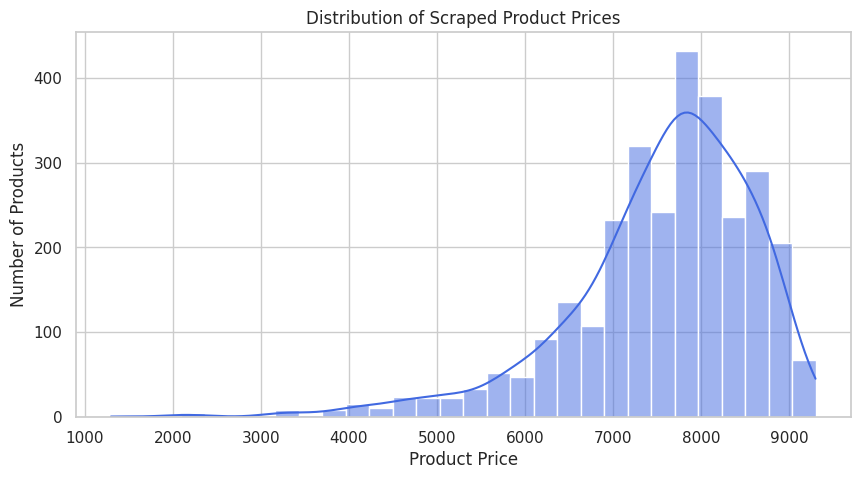

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(
    data=products_df.dropna(subset=["price_numeric"]),
    x="price_numeric",
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Scraped Product Prices")
plt.xlabel("Product Price")
plt.ylabel("Number of Products")
plt.show()

## Visualize Top 10 Most Expensive Products (Old)

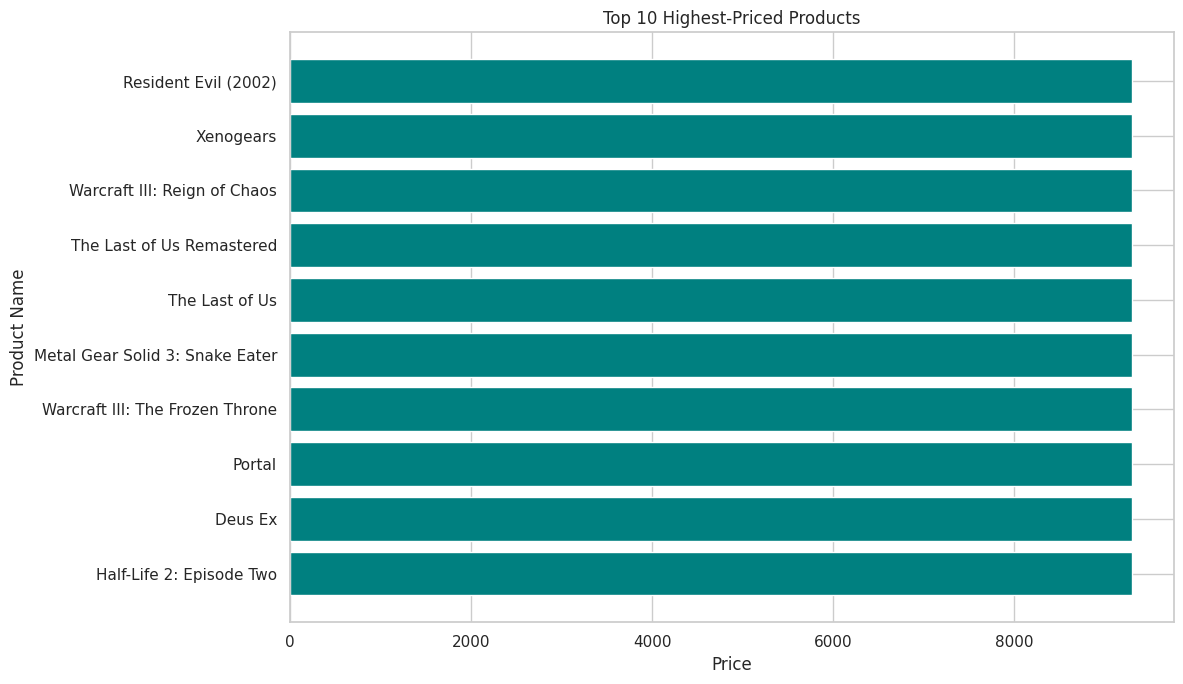

,product_name,price_raw,price_numeric,rating_raw,listing_page
197,Half-Life 2: Episode Two,"92,99 €",9299,None,7
193,Deus Ex,"92,99 €",9299,None,7
183,Portal,"92,99 €",9299,None,6
218,Warcraft III: The Frozen Throne,"92,99 €",9299,None,7
122,Metal Gear Solid 3: Snake Eater,"92,99 €",9299,None,4
20,The Last of Us,"92,99 €",9299,None,1
22,The Last of Us Remastered,"92,99 €",9299,None,1
73,Warcraft III: Reign of Chaos,"92,99 €",9299,None,3
368,Xenogears,"92,99 €",9299,None,12
121,Resident Evil (2002),"92,99 €",9299,None,4


In [33]:
top_10_expensive = (
    products_df
    .dropna(subset=["price_numeric"])
    .sort_values("price_numeric", ascending=False)
    .head(10)
    .sort_values("price_numeric")
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10_expensive["product_name"],
    top_10_expensive["price_numeric"],
    color="teal"
)

plt.title("Top 10 Highest-Priced Products")
plt.xlabel("Price")
plt.ylabel("Product Name")
plt.tight_layout()
plt.show()

display(
    top_10_expensive[
        [
            "product_name",
            "price_raw",
            "price_numeric",
            "rating_raw",
            "listing_page"
        ]
    ]
)

## Visualize Products Extracted Per Page (Old)

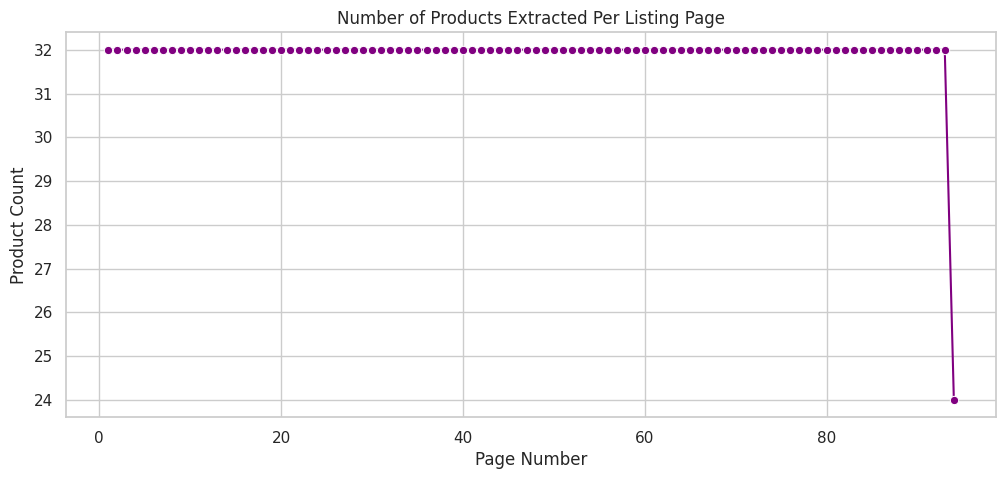

In [34]:
products_per_page = (
    products_df.groupby("listing_page")
    .size()
    .reset_index(name="product_count")
)

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=products_per_page,
    x="listing_page",
    y="product_count",
    marker="o",
    color="purple"
)

plt.title("Number of Products Extracted Per Listing Page")
plt.xlabel("Page Number")
plt.ylabel("Product Count")
plt.show()

## Test `scrape_product_page` (Old)

In [35]:
test_products = scrape_product_page(1)
test_products_df = pd.DataFrame(test_products)

print("Products on page 1:", len(test_products_df))
display(test_products_df.head(10))

Page 1: selector used: .product-card | cards found: 32
Products on page 1: 32


,product_name,price_raw,rating_raw,product_url,image_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",None,https://sandbox.oxylabs.io/products/1,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
1,Super Mario Galaxy,"91,99 €",None,https://sandbox.oxylabs.io/products/2,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
2,Super Mario Galaxy 2,"91,99 €",None,https://sandbox.oxylabs.io/products/3,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
3,Metroid Prime,"89,99 €",None,https://sandbox.oxylabs.io/products/4,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
4,Super Mario Odyssey,"89,99 €",None,https://sandbox.oxylabs.io/products/5,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
5,Halo: Combat Evolved,"87,99 €",None,https://sandbox.oxylabs.io/products/6,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",None,https://sandbox.oxylabs.io/products/7,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
7,NFL 2K1,"62,99 €",None,https://sandbox.oxylabs.io/products/8,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
8,Uncharted 2: Among Thieves,"88,99 €",None,https://sandbox.oxylabs.io/products/9,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1
9,Tekken 3,"91,99 €",None,https://sandbox.oxylabs.io/products/10,"data:image/gif;base64,R0lGODlhAQABAIAAAAAAAP//...",1


## Refine `get_image_link` Function

In [36]:
def get_image_link(card, current_url):
    image = card.select_one("img")

    if image is None:
        return None

    possible_sources = [
        image.get("data-src"),
        image.get("data-lazy-src"),
        image.get("data-original"),
        image.get("srcset"),
        image.get("src")
    ]

    for source in possible_sources:
        if source and not source.startswith("data:image"):
            source = source.split(",")[0].strip().split(" ")[0]
            return urljoin(current_url, source)

    return None

## Test `scrape_product_page` with improved `get_image_link`

In [37]:
test_products = scrape_product_page(1)
test_products_df = pd.DataFrame(test_products)

display(test_products_df.head(10))

Page 1: selector used: .product-card | cards found: 32


,product_name,price_raw,rating_raw,product_url,image_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",None,https://sandbox.oxylabs.io/products/1,None,1
1,Super Mario Galaxy,"91,99 €",None,https://sandbox.oxylabs.io/products/2,None,1
2,Super Mario Galaxy 2,"91,99 €",None,https://sandbox.oxylabs.io/products/3,None,1
3,Metroid Prime,"89,99 €",None,https://sandbox.oxylabs.io/products/4,None,1
4,Super Mario Odyssey,"89,99 €",None,https://sandbox.oxylabs.io/products/5,None,1
5,Halo: Combat Evolved,"87,99 €",None,https://sandbox.oxylabs.io/products/6,None,1
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",None,https://sandbox.oxylabs.io/products/7,None,1
7,NFL 2K1,"62,99 €",None,https://sandbox.oxylabs.io/products/8,None,1
8,Uncharted 2: Among Thieves,"88,99 €",None,https://sandbox.oxylabs.io/products/9,None,1
9,Tekken 3,"91,99 €",None,https://sandbox.oxylabs.io/products/10,None,1


## Invalid Python Syntax (Error from previous turn)

In [38]:
.product-card

SyntaxError: invalid syntax (271735873.py, line 1)

## Updated Main Scraping Logic and Helper Functions

In [39]:
import time
import re
import pandas as pd
import requests

from bs4 import BeautifulSoup
from tqdm.auto import tqdm
from urllib.parse import urljoin


BASE_PRODUCTS_URL = "https://sandbox.oxylabs.io/products"


def clean_text(value):
    return re.sub(r"\s+", " ", str(value)).strip()


def get_first_text(container, selectors):
    for selector in selectors:
        element = container.select_one(selector)

        if element:
            value = clean_text(
                element.get_text(" ", strip=True)
            )

            if value:
                return value

    return None


def get_product_link(card, current_url):
    link = card.select_one("a[href*='/products/']")

    if link:
        return urljoin(
            current_url,
            link.get("href")
        )

    return None


def get_image_link(card, current_url):
    image = card.select_one("img")

    if image is None:
        return None

    possible_sources = [
        image.get("data-src"),
        image.get("data-lazy-src"),
        image.get("data-original"),
        image.get("srcset"),
        image.get("src")
    ]

    for source in possible_sources:
        if source and not source.startswith("data:image"):
            source = source.split(",")[0].strip().split(" ")[0]

            return urljoin(
                current_url,
                source
            )

    return None


def scrape_product_page(page_number):
    page_url = f"{BASE_PRODUCTS_URL}?page={page_number}"

    response = requests.get(
        page_url,
        headers=HEADERS,
        timeout=20
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    cards = soup.select(".product-card")

    records = []

    for card in cards:
        product_name = get_first_text(
            card,
            [
                "h1",
                "h2",
                "h3",
                "h4",
                "[class*='title']",
                "[class*='name']"
            ]
        )

        price_raw = get_first_text(
            card,
            [
                "[class*='price']",
                "[class*='Price']"
            ]
        )

        product_url = get_product_link(card, page_url)
        image_url = get_image_link(card, page_url)

        if product_name and product_url:
            records.append({
                "product_name": product_name,
                "price_raw": price_raw,
                "product_url": product_url,
                "image_url": image_url,
                "listing_page": page_number
            })

    return records

## Test Updated Scrape Product Page Function

In [40]:
page_1_products = scrape_product_page(1)

page_1_df = pd.DataFrame(page_1_products)

print("Products extracted from page 1:", len(page_1_df))

display(page_1_df.head(10))

Products extracted from page 1: 32


,product_name,price_raw,product_url,image_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",https://sandbox.oxylabs.io/products/1,None,1
1,Super Mario Galaxy,"91,99 €",https://sandbox.oxylabs.io/products/2,None,1
2,Super Mario Galaxy 2,"91,99 €",https://sandbox.oxylabs.io/products/3,None,1
3,Metroid Prime,"89,99 €",https://sandbox.oxylabs.io/products/4,None,1
4,Super Mario Odyssey,"89,99 €",https://sandbox.oxylabs.io/products/5,None,1
5,Halo: Combat Evolved,"87,99 €",https://sandbox.oxylabs.io/products/6,None,1
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",https://sandbox.oxylabs.io/products/7,None,1
7,NFL 2K1,"62,99 €",https://sandbox.oxylabs.io/products/8,None,1
8,Uncharted 2: Among Thieves,"88,99 €",https://sandbox.oxylabs.io/products/9,None,1
9,Tekken 3,"91,99 €",https://sandbox.oxylabs.io/products/10,None,1


## Execute Full Product Scraping Across All Pages

In [41]:
all_products = []

TOTAL_PAGES = 94

for page_number in tqdm(
    range(1, TOTAL_PAGES + 1),
    desc="Scraping Oxylabs product pages"
):
    try:
        records = scrape_product_page(page_number)

        all_products.extend(records)

        time.sleep(0.5)

    except requests.exceptions.RequestException as error:
        print(f"Request error on page {page_number}: {error}")

    except Exception as error:
        print(f"Unexpected error on page {page_number}: {error}")

products_df = pd.DataFrame(all_products)

print("Raw records collected:", len(products_df))

display(products_df.head())

Scraping Oxylabs product pages:   0%|          | 0/94 [00:00<?, ?it/s]

Raw records collected: 3000


,product_name,price_raw,product_url,image_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",https://sandbox.oxylabs.io/products/1,None,1
1,Super Mario Galaxy,"91,99 €",https://sandbox.oxylabs.io/products/2,None,1
2,Super Mario Galaxy 2,"91,99 €",https://sandbox.oxylabs.io/products/3,None,1
3,Metroid Prime,"89,99 €",https://sandbox.oxylabs.io/products/4,None,1
4,Super Mario Odyssey,"89,99 €",https://sandbox.oxylabs.io/products/5,None,1


## Clean and Transform Scraped Price Data

In [42]:
def convert_euro_price(price):
    if pd.isna(price):
        return None

    price = str(price)

    price = price.replace("€", "")
    price = price.replace("\xa0", "")
    price = price.replace(" ", "")

    price = price.replace(".", "")
    price = price.replace(",", ".")

    return pd.to_numeric(price, errors="coerce")


products_df["price_eur"] = products_df["price_raw"].apply(
    convert_euro_price
)

products_df = products_df.drop_duplicates(
    subset=["product_url"]
).reset_index(drop=True)

products_df = products_df.dropna(
    subset=["product_name", "price_eur"]
).reset_index(drop=True)

print("Final dataset shape:", products_df.shape)

print("\nMissing values:")
print(products_df.isnull().sum())

print("\nPrice summary:")
display(products_df["price_eur"].describe())

display(products_df.head(10))

Final dataset shape: (3000, 6)

Missing values:
product_name       0
price_raw          0
product_url        0
image_url       3000
listing_page       0
price_eur          0
dtype: int64

Price summary:


,price_eur
count,3000.000000
mean,75.385000
std,10.883005
min,12.990000
25%,70.990000
50%,76.990000
75%,82.990000
max,92.990000


,product_name,price_raw,product_url,image_url,listing_page,price_eur
0,The Legend of Zelda: Ocarina of Time,"91,99 €",https://sandbox.oxylabs.io/products/1,None,1,91.99
1,Super Mario Galaxy,"91,99 €",https://sandbox.oxylabs.io/products/2,None,1,91.99
2,Super Mario Galaxy 2,"91,99 €",https://sandbox.oxylabs.io/products/3,None,1,91.99
3,Metroid Prime,"89,99 €",https://sandbox.oxylabs.io/products/4,None,1,89.99
4,Super Mario Odyssey,"89,99 €",https://sandbox.oxylabs.io/products/5,None,1,89.99
5,Halo: Combat Evolved,"87,99 €",https://sandbox.oxylabs.io/products/6,None,1,87.99
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",https://sandbox.oxylabs.io/products/7,None,1,83.99
7,NFL 2K1,"62,99 €",https://sandbox.oxylabs.io/products/8,None,1,62.99
8,Uncharted 2: Among Thieves,"88,99 €",https://sandbox.oxylabs.io/products/9,None,1,88.99
9,Tekken 3,"91,99 €",https://sandbox.oxylabs.io/products/10,None,1,91.99


## Display Cleaned Product Data Sample

In [43]:
display(
    products_df[
        [
            "product_name",
            "price_raw",
            "price_eur",
            "product_url",
            "listing_page"
        ]
    ].head(15)
)

,product_name,price_raw,price_eur,product_url,listing_page
0,The Legend of Zelda: Ocarina of Time,"91,99 €",91.99,https://sandbox.oxylabs.io/products/1,1
1,Super Mario Galaxy,"91,99 €",91.99,https://sandbox.oxylabs.io/products/2,1
2,Super Mario Galaxy 2,"91,99 €",91.99,https://sandbox.oxylabs.io/products/3,1
3,Metroid Prime,"89,99 €",89.99,https://sandbox.oxylabs.io/products/4,1
4,Super Mario Odyssey,"89,99 €",89.99,https://sandbox.oxylabs.io/products/5,1
5,Halo: Combat Evolved,"87,99 €",87.99,https://sandbox.oxylabs.io/products/6,1
6,The House in Fata Morgana - Dreams of the Reve...,"83,99 €",83.99,https://sandbox.oxylabs.io/products/7,1
7,NFL 2K1,"62,99 €",62.99,https://sandbox.oxylabs.io/products/8,1
8,Uncharted 2: Among Thieves,"88,99 €",88.99,https://sandbox.oxylabs.io/products/9,1
9,Tekken 3,"91,99 €",91.99,https://sandbox.oxylabs.io/products/10,1


## Save Final Processed Data to CSV

In [44]:
products_df.to_csv(
    "oxylabs_games_products_scraped.csv",
    index=False
)

print("Saved successfully: oxylabs_games_products_scraped.csv")

Saved successfully: oxylabs_games_products_scraped.csv


## Download Scraped Data

In [45]:
from google.colab import files

files.download("oxylabs_games_products_scraped.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Visualize Distribution of Product Prices

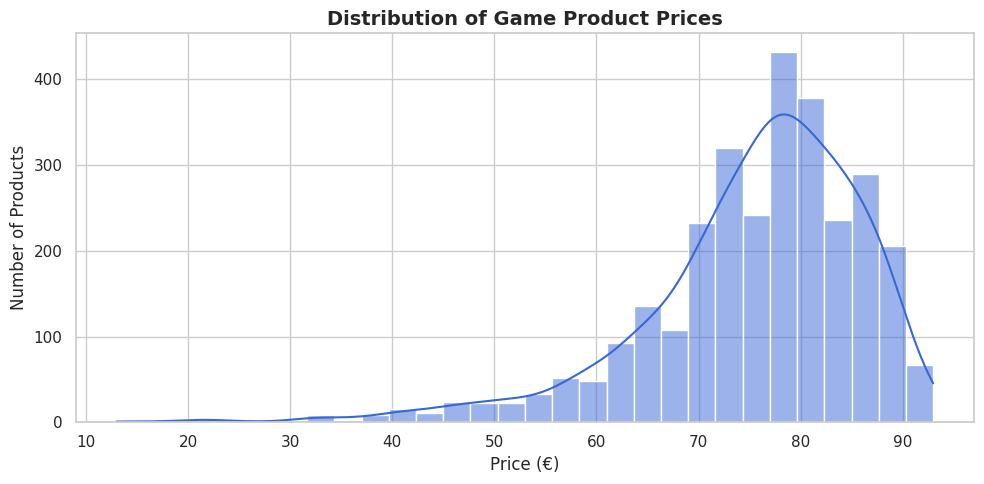

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

sns.histplot(
    data=products_df,
    x="price_eur",
    bins=30,
    kde=True,
    color="#3867d6"
)

plt.title(
    "Distribution of Game Product Prices",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Price (€)")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

## Visualize Products Extracted Per Page

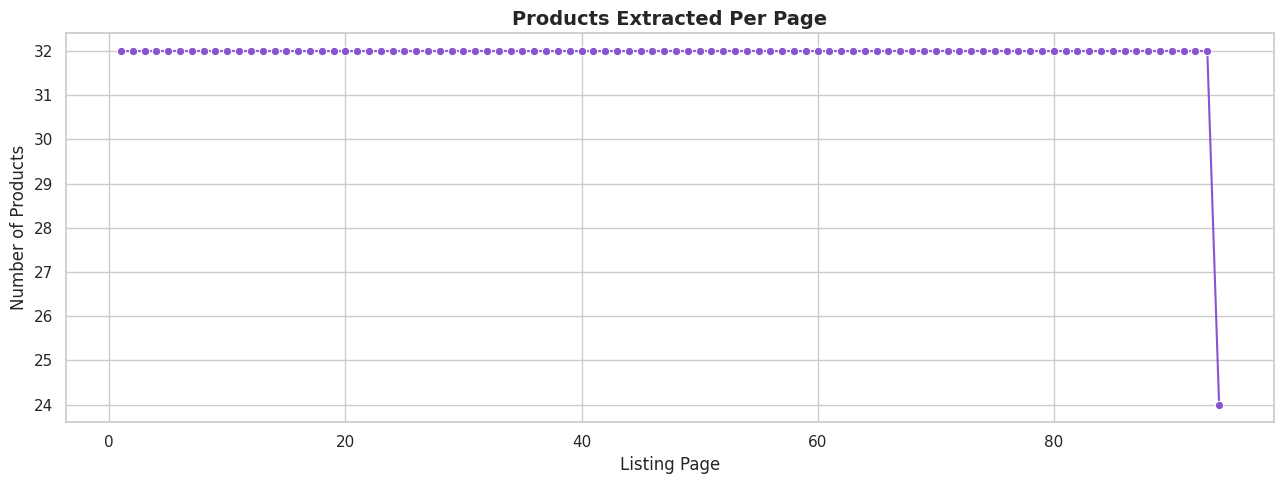

In [47]:
products_per_page = (
    products_df.groupby("listing_page")
    .size()
    .reset_index(name="product_count")
)

plt.figure(figsize=(13, 5))

sns.lineplot(
    data=products_per_page,
    x="listing_page",
    y="product_count",
    marker="o",
    color="#8854d0"
)

plt.title(
    "Products Extracted Per Page",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Listing Page")
plt.ylabel("Number of Products")

plt.tight_layout()
plt.show()

## Visualize Top 10 Most Expensive Products

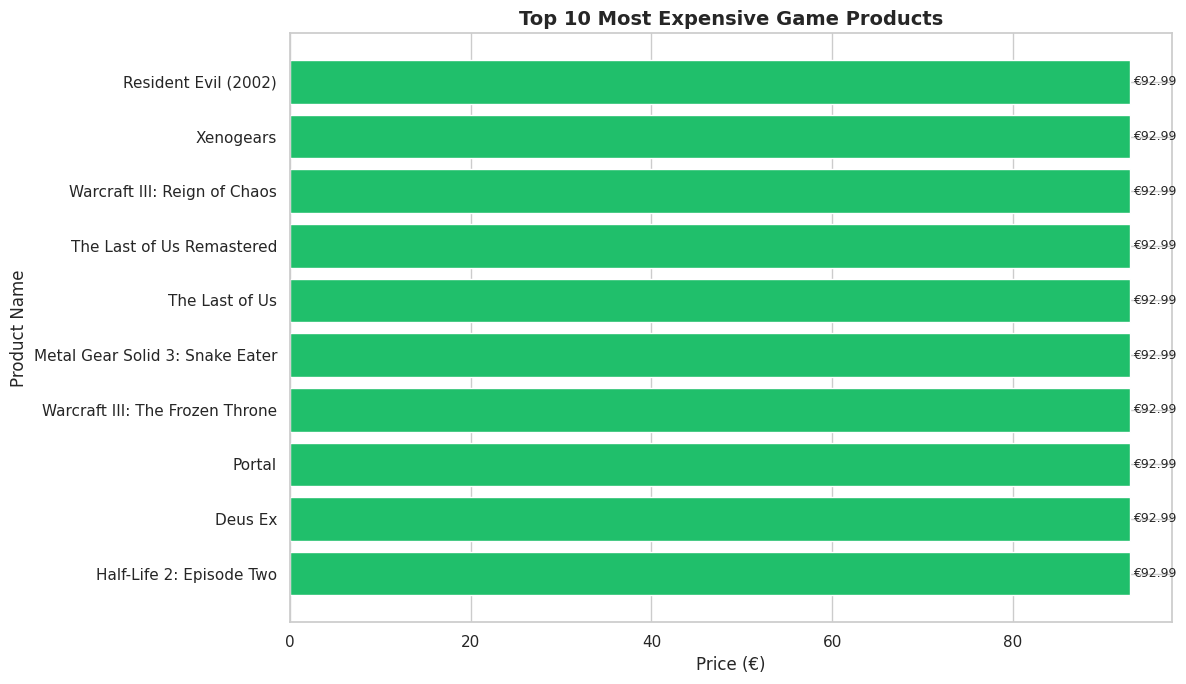

,product_name,price_raw,price_eur,product_url
197,Half-Life 2: Episode Two,"92,99 €",92.99,https://sandbox.oxylabs.io/products/198
193,Deus Ex,"92,99 €",92.99,https://sandbox.oxylabs.io/products/194
183,Portal,"92,99 €",92.99,https://sandbox.oxylabs.io/products/184
218,Warcraft III: The Frozen Throne,"92,99 €",92.99,https://sandbox.oxylabs.io/products/219
122,Metal Gear Solid 3: Snake Eater,"92,99 €",92.99,https://sandbox.oxylabs.io/products/123
20,The Last of Us,"92,99 €",92.99,https://sandbox.oxylabs.io/products/21
22,The Last of Us Remastered,"92,99 €",92.99,https://sandbox.oxylabs.io/products/23
73,Warcraft III: Reign of Chaos,"92,99 €",92.99,https://sandbox.oxylabs.io/products/74
368,Xenogears,"92,99 €",92.99,https://sandbox.oxylabs.io/products/369
121,Resident Evil (2002),"92,99 €",92.99,https://sandbox.oxylabs.io/products/122


In [49]:
top_expensive = (
    products_df.sort_values(
        "price_eur",
        ascending=False
    )
    .head(10)
    .sort_values("price_eur")
)

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top_expensive["product_name"],
    top_expensive["price_eur"],
    color="#20bf6b"
)

plt.title(
    "Top 10 Most Expensive Game Products",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Price (€)")
plt.ylabel("Product Name")

for bar, price in zip(bars, top_expensive["price_eur"]):
    plt.text(
        price + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"€{price:.2f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

display(
    top_expensive[
        [
            "product_name",
            "price_raw",
            "price_eur",
            "product_url"
        ]
    ]
)

## Display Final DataFrame Info

In [50]:
print(products_df.shape)
print(products_df["price_eur"].describe())
display(products_df.head())

(3000, 6)
count    3000.000000
mean       75.385000
std        10.883005
min        12.990000
25%        70.990000
50%        76.990000
75%        82.990000
max        92.990000
Name: price_eur, dtype: float64


,product_name,price_raw,product_url,image_url,listing_page,price_eur
0,The Legend of Zelda: Ocarina of Time,"91,99 €",https://sandbox.oxylabs.io/products/1,None,1,91.99
1,Super Mario Galaxy,"91,99 €",https://sandbox.oxylabs.io/products/2,None,1,91.99
2,Super Mario Galaxy 2,"91,99 €",https://sandbox.oxylabs.io/products/3,None,1,91.99
3,Metroid Prime,"89,99 €",https://sandbox.oxylabs.io/products/4,None,1,89.99
4,Super Mario Odyssey,"89,99 €",https://sandbox.oxylabs.io/products/5,None,1,89.99
